In [219]:
%load_ext autoreload
%autoreload 2
import sys
import interpax

sys.path.append("../modules")
sys.path.append("../modules/TransdimensionalSplineFitting")
from loguru import logger
import numpy as np
import gwpopulation
gwpopulation.set_backend('jax')
from gwpopulation.models.mass import SinglePeakSmoothedMassDistribution
from gwpopulation.models.redshift import MadauDickinsonRedshift
from spline_redshift import createSplineRedshift
import pickle
import cloudpickle
from pathlib import Path

import json


from popstock_tsf_helper import (create_injected_OmegaGW,
                                 get_sigma_from_noise_curves,
                                 create_popOmegaGW)
import transdimensional_spline_fitting as tsf
from tsf_models import RedshiftSampler, RedshiftSamplerJAX
import argparse
import lal
lal.swig_redirect_standard_output_error(False)

import matplotlib.pyplot as plt

from jax import lax

import jax

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [220]:
import lal
lal.swig_redirect_standard_output_error(False)

False

In [221]:


def propagate_last_selected(x, a, mask):

    first_idx = jnp.argmax(mask)
    def step(carry, inputs):
        x_carry, a_carry = carry
        x_i, a_i, m_i = inputs
        new_x = jnp.where(m_i, x_i, x_carry)
        new_a = jnp.where(m_i, a_i, a_carry)
        return (new_x, new_a), (new_x, new_a)
    
    init = (x[first_idx], a[first_idx])
    _, (out_x, out_a) = jax.lax.scan(step, init, xs=(x, a, mask))
    return out_x, out_a

jpls = jax.jit(propagate_last_selected)

In [222]:
Lambda_0 =  {'alpha': 1.9, 'beta': 3.4, 'delta_m': 3., 'lam': 0.04,
            'mmax': 100., 'mmin': 4., 'mpp': 33., 'sigpp':5., 'gamma': 3,
            'kappa': 5.6, 'z_peak': 2.4, 'rate': 25}

In [223]:
mass_obj = SinglePeakSmoothedMassDistribution()
redshift_obj = MadauDickinsonRedshift(z_max=10)

In [224]:
Tobs = 86400 * 365.25 * (1./365.25) * 1/24
freqs = np.arange(10, 200, 0.25)
sigma = get_sigma_from_noise_curves(['CE'], freqs, Tobs)

max_knots=30

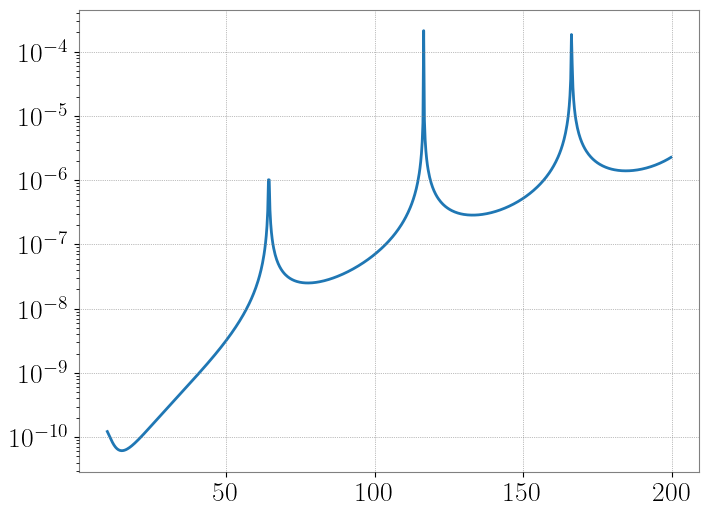

In [225]:
fig, ax = plt.subplots()
ax.plot(freqs, sigma)
plt.yscale("log")
plt.show()

In [290]:
xvals, spline_pop, injected_pop, amplitudes, configuration, Lambda_start = \
    create_injected_OmegaGW(freqs, Lambda_0, 10_000,
                            mass_obj, redshift_obj, backend='jax', max_knots=max_knots)

Initializing with the following models: 
mass: <gwpopulation.models.mass.SinglePeakSmoothedMassDistribution object at 0x36f833fa0>
redshift: <gwpopulation.models.redshift.MadauDickinsonRedshift object at 0x31f2af010>
Using 1000000, got 5327 out of target 10000 samples after iteration 0
Efficiency: 0.005327, trying 877229 samples in next iteration
-----------------------------------------------------------
Using 877229, got 9977 out of target 10000 samples after iteration 1
Efficiency: 0.005300782349876714, trying 1009284 samples in next iteration
-----------------------------------------------------------


18:52 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Using 1009284, got 15309 out of target 10000 samples after iteration 2
Efficiency: 0.005282953063756089, trying 883596 samples in next iteration
-----------------------------------------------------------
Drawing redshift samples
{'gamma': 3, 'kappa': 5.6, 'z_peak': 2.4}
Using multiprocessing, no status bar currently supported... 
Initializing with the following models: 
mass: <gwpopulation.models.mass.SinglePeakSmoothedMassDistribution object at 0x36f833fa0>
redshift: <spline_redshift.createSplineRedshift.<locals>.SplineRedshift object at 0x3dc660d60>
Using 1000000, got 5358 out of target 10000 samples after iteration 0
Efficiency: 0.005358, trying 866368 samples in next iteration
-----------------------------------------------------------
Using 866368, got 10079 out of target 10000 samples after iteration 1
Efficiency: 0.005449185565487184, trying 968768 samples in next iteration
-----------------------------------------------------------


18:52 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Drawing redshift samples
{'amplitudes0': 1.512205203321566, 'amplitudes1': 3.263704701910919, 'amplitudes2': 5.921601609739491, 'amplitudes3': 9.421786517878697, 'amplitudes4': 13.333931245740882, 'amplitudes5': 16.842671422908023, 'amplitudes6': 19.09404007168998, 'amplitudes7': 19.7151226702304, 'amplitudes8': 18.957527702872994, 'amplitudes9': 17.376382615599198, 'amplitudes10': 15.476117778075803, 'amplitudes11': 13.576027701546268, 'amplitudes12': 11.832175446991064, 'amplitudes13': 10.29937583653203, 'amplitudes14': 8.980852984784951, 'amplitudes15': 7.8577279586674225, 'amplitudes16': 6.904100253306804, 'amplitudes17': 6.09395470238623, 'amplitudes18': 5.403849715850053, 'amplitudes19': 4.813757771133172, 'amplitudes20': 4.306941834267268, 'amplitudes21': 3.8696145269551843, 'amplitudes22': 3.4904573727666772, 'amplitudes23': 3.160211673420738, 'amplitudes24': 2.8712373471077512, 'amplitudes25': 2.6172759996941037, 'amplitudes26': 2.393189752249963, 'amplitudes27': 2.19465964422

In [291]:
%%timeit
spline_pop.calculate_omega_gw(Lambda_start)

35.1 ms ± 1.44 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


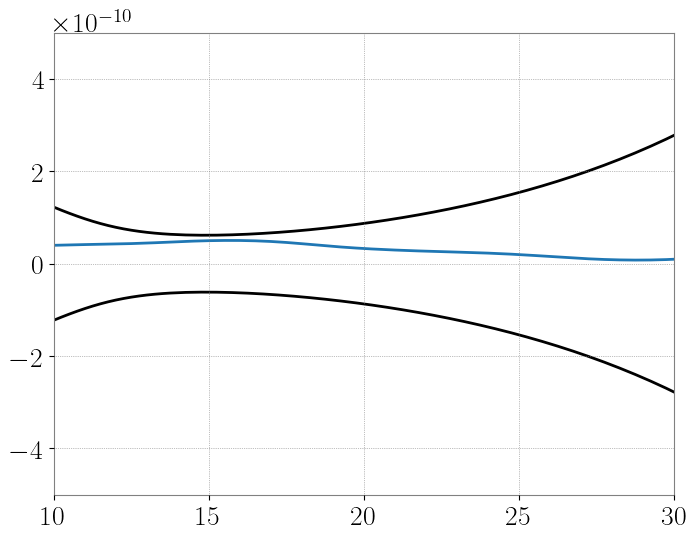

In [292]:
spline_pop.calculate_omega_gw(Lambda_start)
injected_pop.calculate_omega_gw(Lambda_start)
plt.plot(freqs, spline_pop.omega_gw - injected_pop.omega_gw)
# plt.plot(freqs, )
plt.plot(freqs, sigma, c='k')
plt.plot(freqs, -sigma, c='k')
plt.xlim(10, 30)
plt.ylim(-5e-10, 5e-10)
plt.show()
# plt.xscale("log")
# plt.yscale("log")
# plt.ylim(1e-10, 1e-7)

In [293]:
spline_pop.proposal_samples['mass_1_source']

array([15.56950344, 26.7328688 ,  5.51501527, ...,  7.17696034,
        9.09641371, 41.42319388])

In [294]:
import jax.numpy as jnp

from popstock.constants import H0

def make_calculate_omgw(spline_pop):

    H0_si = H0.si.value
    samples = spline_pop.proposal_samples
    p_masses = spline_pop.calculate_p_masses(samples, {key: Lambda_0[key] for key in spline_pop.model_args['mass']})
    p_spins = spline_pop.calculate_p_spin_models(samples, Lambda_0)
    def calculate_probabilities(Lambda_redshift):
        p_redshift = spline_pop.calculate_p_z(samples, Lambda_redshift)
        return p_masses*p_spins*p_redshift
    
    def calculate_weights(Lambda):
        probabilities = calculate_probabilities(Lambda)
        weights = (probabilities / spline_pop.pdraws)
        weights = jnp.where(probabilities!=0.0, weights, 0)
        return weights
    def omegagw(Lambda):
        redshift_model_norm_in_Gpc3 = spline_pop.models['redshift'].normalisation(Lambda)/1.e9
        Rate_norm_in_Gpc3_per_seconds = Lambda['rate']/(60*60*24*365)
        Rate_norm = redshift_model_norm_in_Gpc3 * Rate_norm_in_Gpc3_per_seconds
        weights = calculate_weights(Lambda)
        weighted_energy = jnp.nansum(weights[:, None] * spline_pop.wave_energies, axis=0) / weights.size
        conv = spline_pop.frequency_array_xp**3 * 4. * jnp.pi**2 / (3 * H0_si**2)
        return Rate_norm * conv * weighted_energy
    return omegagw
import jax
calc_omgw = make_calculate_omgw(spline_pop)
jco = jax.jit(calc_omgw)
calc_omgw_v_and_grad = jax.value_and_grad(calc_omgw)

In [295]:
%%timeit
jco(Lambda_start)

299 μs ± 123 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [296]:
Lambda_start['mpp'] = 33.0

In [297]:
for ii in range(max_knots):
    Lambda_start[f'configuration{ii}'] = 1.

In [298]:
fake_data = np.random.randn(freqs.size) * sigma + injected_pop.omega_gw

data_object = tsf.SmoothCurveDataObj(freqs, fake_data, sigma)

In [299]:
# rs_sampler = RedshiftSampler(data_object, max_knots,
#                              [0.01, 10], [0, 30],
#                              min_knots=0, birth_gauss_scalefac=.05)
rs_sampler_jax = RedshiftSamplerJAX(data_object, max_knots,
                             [0.01, 10], [0, 50],
                             min_knots=2, birth_gauss_scalefac=0.1, birth_uniform_frac=0.3,
                                   )

In [300]:
rs_sampler_jax.set_base_population_information(jax.jit(calc_omgw), spline_pop, Lambda_start)

In [301]:
start_zvals = np.array([Lambda_start[f'xvals{ii}'] for ii in range(max_knots)])
start_amplitudes = np.array([Lambda_start[f'amplitudes{ii}'] for ii in range(max_knots)])

In [302]:
rs_sampler_jax.ln_likelihood(np.ones(max_knots).astype(bool), start_amplitudes, start_zvals)

11699.37056031857

In [321]:
results = rs_sampler_jax.sample(20_000,
                            start_knots=start_zvals,
                            start_heights=start_amplitudes,
                            start_config=np.ones(max_knots).astype(bool),
                            proposal_weights=[1, 1, 1, 1, 1], 
                           )

starting ll: 11699.396676309356


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:27<00:00, 228.07it/s]


In [322]:
for ii in range(5):
    mask = results.move_types==ii
    print(f"move {ii} acceptance fraction: {np.round(np.sum(results.acceptances[mask]) / np.sum(mask), 3)} for {np.sum(results.acceptances[mask])} out of {np.sum(mask)} proposals")

move 0 acceptance fraction: 0.11 for 443 out of 4018 proposals
move 1 acceptance fraction: 0.117 for 469 out of 4002 proposals
move 2 acceptance fraction: 0.285 for 1144 out of 4013 proposals
move 3 acceptance fraction: 0.341 for 1350 out of 3963 proposals
move 4 acceptance fraction: 0.721 for 2886 out of 4004 proposals


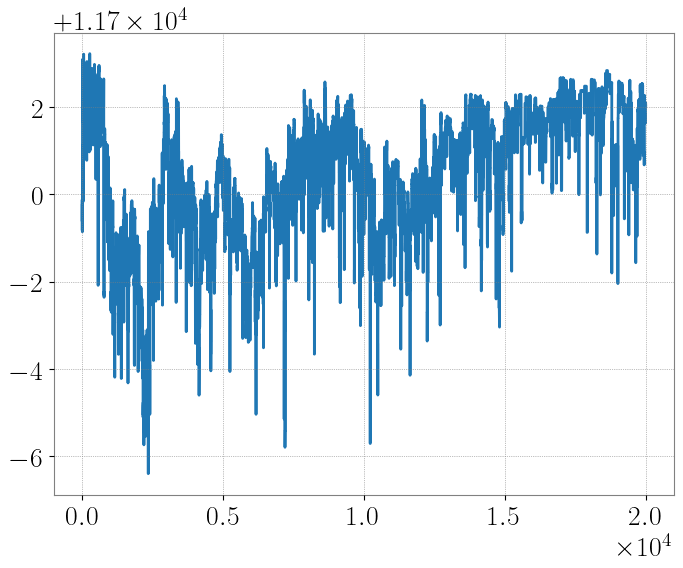

In [325]:
plt.plot(results.lls)
# plt.ylim(0, 100_000)

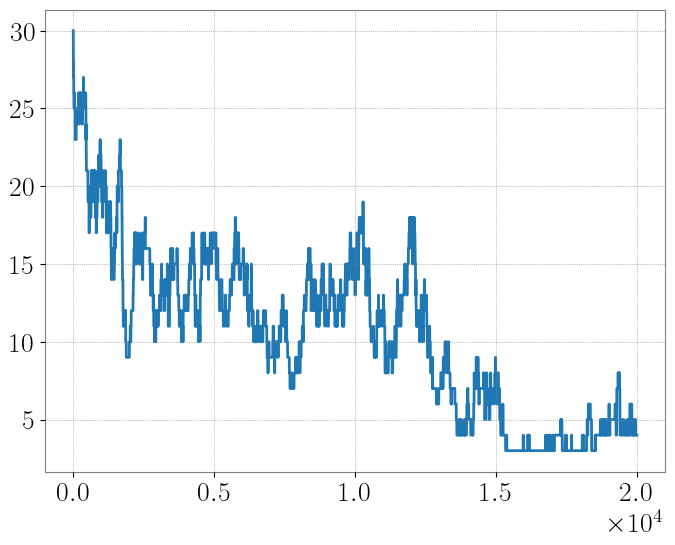

In [326]:
plt.plot(results.configurations.sum(axis=1))

In [327]:
offset=0
start=80_000
end=100_000
skip=20
amps = []
for ii in np.arange(start, end, skip):
    # xvals_tmp = results.knots[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # amplitudes_tmp = results.heights[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # plt.plot(zs, np.interp(zs, xvals_tmp, amplitudes_tmp), c='r', alpha=0.1)
    
    x, a = jpls(results.knots[ii+offset, :], results.heights[ii+offset, :], results.configurations[ii+offset, :])

    # a = propagate_last_selected(, results.configurations[ii+offset, :])
    tmp = interpax.interp1d(zs, x, a, extrap=True, method='linear')

    plt.plot(zs, tmp, c='C0', alpha=0.1)
    amps.append(tmp)
plt.plot(zs, interpax.interp1d(zs, xvals, amplitudes, extrap=True, method='linear'), c='k', ls='--')
plt.ylim(-5, 100)
# plt.yscale("log")
# plt.fill_between(zs, *np.percentile(np.array(amps), [16, 84], axis=0))
# plt.plot(zs, np.interp(zs, start_zvals, start_amplitudes), c='g')

IndexError: index 80000 is out of bounds for axis 0 with size 20000

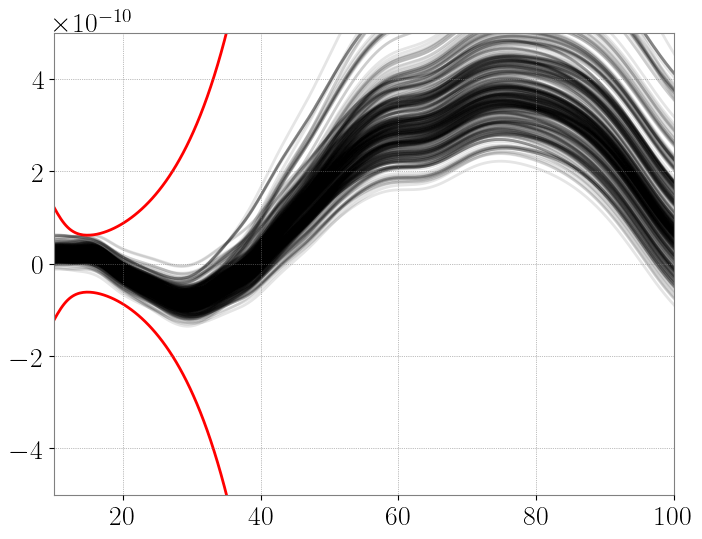

In [315]:
for ii in range(5_000, 10_000, 10):
    Lambda_start.update({f'configuration{kk}': results.configurations[ii, kk] for kk in range(max_knots)})
    Lambda_start.update({f'xvals{kk}': results.knots[ii, kk] for kk in range(max_knots)})
    Lambda_start.update({f'amplitudes{kk}': results.heights[ii, kk] for kk in range(max_knots)})
    omgw = jco(Lambda_start)
    plt.plot(freqs, omgw - injected_pop.omega_gw, c='k', alpha=0.1)
plt.plot(freqs[:400], sigma[:400], c='r')
plt.plot(freqs[:400], -sigma[:400], c='r')
plt.xlim(10, 100)
plt.ylim(-5e-10, 5e-10)
# plt.plot(freqs, injected_pop.omega_gw, alpha=1, ls='--', c='r')
plt.show()

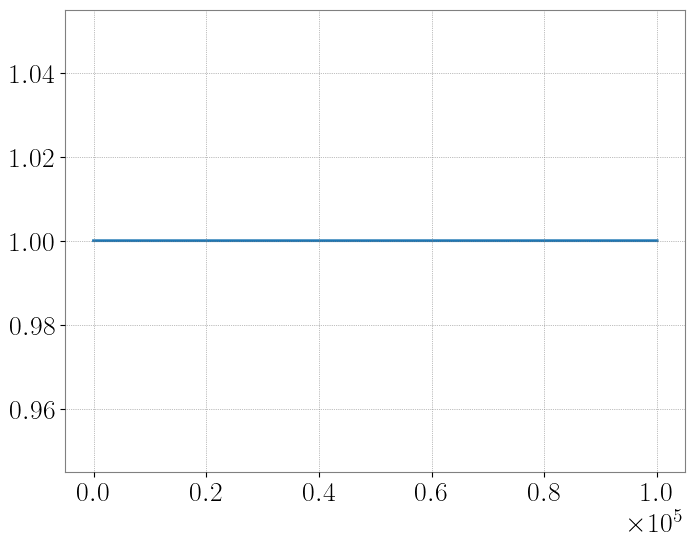

In [287]:
plt.plot(results.configurations[:, 0])

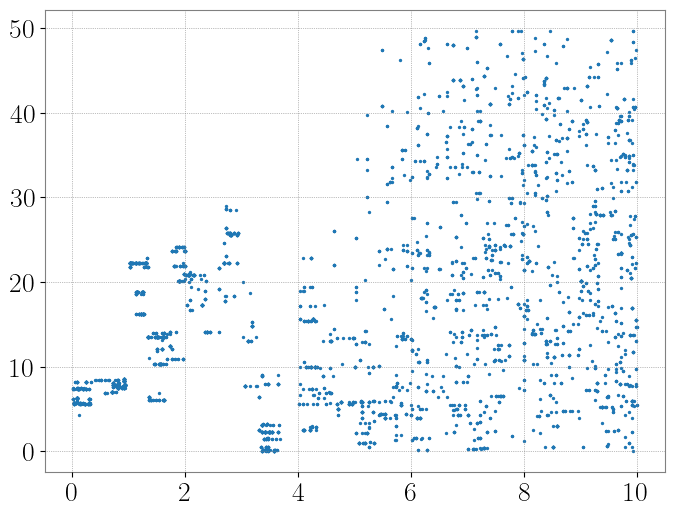

In [288]:
for ii in range(start, end, skip):
    plt.scatter(results.knots[ii, results.configurations[ii].astype(bool)],
                results.heights[ii, results.configurations[ii].astype(bool)],
                c='C0',
                s=2)
plt.show()

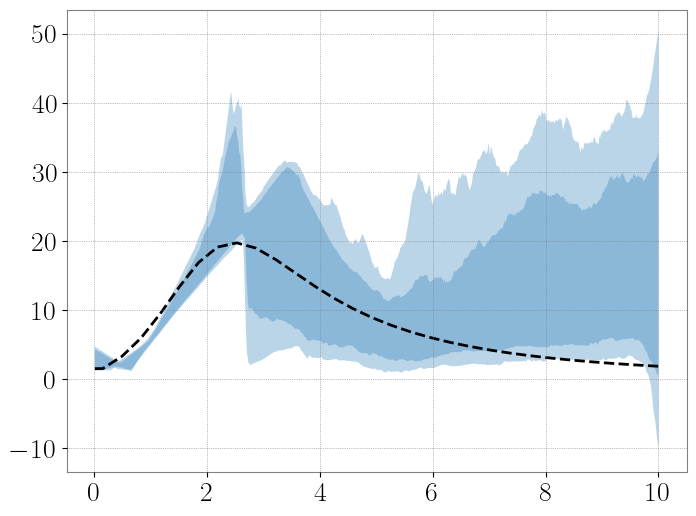

In [320]:

amps = []
for ii in np.arange(start, end, skip):
    # xvals_tmp = results.knots[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # amplitudes_tmp = results.heights[ii+offset, results.configurations[ii+offset, :].astype(bool)]
    # plt.plot(zs, np.interp(zs, xvals_tmp, amplitudes_tmp), c='r', alpha=0.1)
    
    x, a = jpls(results.knots[ii+offset, :], results.heights[ii+offset, :], results.configurations[ii+offset, :])
    # a = propagate_last_selected(, results.configurations[ii+offset, :])
    tmp = interpax.interp1d(zs, x, a, extrap=True, method='linear')
    # plt.plot(zs, tmp, c='C0', alpha=0.1)
    amps.append(tmp)
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='k', ls='--')
plt.fill_between(zs, *np.percentile(np.array(amps), [16, 84], axis=0), alpha=0.3, facecolor='C0')
plt.fill_between(zs, *np.percentile(np.array(amps), [5, 95], axis=0), alpha=0.3, facecolor='C0')
# plt.plot(zs, np.interp(zs, start_zvals, start_amplitudes), c='g')

In [328]:
a = [1, 2, 3, 4]
b = 3
print(np.maximum(a, b))

[3 3 3 4]


In [48]:
print(results.knots[ii, :])
print(results.knots[ii, results.configurations[ii].astype(bool)])

[0.85214081 1.12348135 0.74699596 1.04698151 1.34880427
 1.81779632 2.10417375 2.54492159 2.6961733  3.11218317
 3.56781127 3.84472752 4.32865711 4.60010535 4.82130109
 5.2526031  5.63151905 5.71222054 6.10248184 6.54209131
 6.82811049 7.05147673 7.47294308 7.93451294 8.03490202
 8.60803129 8.85598668 9.30751481 9.5183434  9.85147074]
[0.85214081 1.12348135 1.04698151 2.54492159 3.11218317
 3.56781127 3.84472752 4.82130109 5.2526031  5.71222054
 6.54209131 6.82811049 7.47294308 8.03490202 8.60803129
 8.85598668 9.30751481 9.85147074]


In [49]:

x, a = jplsn(results.knots[ii+offset, :], results.heights[ii+offset, :], results.configurations[ii+offset, :])
print(x, a)

NameError: name 'jplsn' is not defined

## Numpyro

In [ ]:
from numpyro import distributions as dist, infer
from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam
import numpyro

# from numpyro.handlers import disable_jit
def model(max_knots=max_knots):
    alpha = numpyro.sample("alpha", dist.LogUniform(0.001, 1))
    configs = numpyro.sample("configurations", dist.Bernoulli(alpha).expand([max_knots]))
    # mydict = {f'configuration{ii}':1. for ii in range(max_knots)}
    mydict = {f'configuration{ii}': configs[ii] for ii in range(max_knots)}
    amplitudes = numpyro.sample("amplitudes", dist.Uniform(0, 30).expand([max_knots]))
    mydict.update({f'amplitudes{ii}': amplitudes[ii] for ii in range(max_knots)})
    # delta_x = (10 - 0.01) / max_knots
    # xvals = numpyro.sample("xvaloffsets", dist.Uniform(0, delta_x).expand([max_knots]))
    # xvals = numpyro.deterministic("xvals", xvals + np.arange(max_knots) * delta_x)
    mydict.update({f'xvals{ii}': xvals[ii] for ii in range(max_knots)})
    mydict.update(Lambda_0)
    rate = numpyro.sample("rate", dist.Uniform(10, 50))
    mydict.update({"rate": rate})
    omega = calc_omgw(mydict)
    numpyro.deterministic('omegagw', omega)

    ll = numpyro.deterministic("ll", dist.Normal(omega, sigma).log_prob(fake_data).sum())
    numpyro.factor("loglike", ll)

In [ ]:
Lambda_0

In [ ]:
# amplitudes_start = np.array([Lambda_start[f'amplitudes{ii}'] for ii in range(max_knots)])
# xvals_start = np.array([Lambda_start[f'xvals{ii}'] for ii in range(max_knots)])

# params = {
#     "amplitudes": jnp.array(amplitudes),
#     "configs": jnp.ones(max_knots),
#     "rate": 25.
# }

# unconstrained = infer.util.unconstrain_fn(model, (), {"max_knots": max_knots}, params)

In [ ]:
# print(amplitudes_start)
# print(amplitudes)

In [ ]:
Lambda_start['rate'] = 25.0

In [ ]:
def ll(params):
    omgw = jco(params)
    return dist.Normal(omgw, sigma).log_prob(fake_data).sum()

jll = jax.jit(ll)

In [ ]:
%%timeit
jll(Lambda_start)

In [ ]:
spline_pop.calculate_omega_gw(Lambda_start)

In [ ]:
injected_pop.calculate_omega_gw(Lambda_start)

In [ ]:
plt.plot(freqs, spline_pop.omega_gw)
plt.plot(freqs, injected_pop.omega_gw)
plt.plot(freqs, np.abs(fake_data), alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-10, 1e-7)

In [ ]:
plt.plot(freqs, calc_omgw(Lambda_start) - injected_pop.omega_gw)

In [ ]:
from numpyro.infer import MCMC, NUTS, ESS, DiscreteHMCGibbs

for ii in range(max_knots):
    Lambda_start[f'configuration{ii}'] = 1.


# kernel = NUTS(model , max_tree_depth=4, dense_mass=False)
kernel = DiscreteHMCGibbs(NUTS(model, max_tree_depth=3), modified=True)
# >>>mcmc = MCMC(kernel, num_warmup=1000, num_samples=100000, progress_bar=False)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=200)
mcmc.run(jax.random.PRNGKey(12345))# , init_params=unconstrained)

In [ ]:
samples = mcmc.get_samples()

In [ ]:
mcmc.print_summary()

In [ ]:
zs = np.linspace(0.01, 10, num=1000)

In [ ]:
for ii in range(0, 200):
    x, a = jpls(xvals, samples['amplitudes'][ii, :], samples['configurations'][ii, :])

    # a = propagate_last_selected(samples['amplitudes'][ii, :], samples['configurations'][ii, :])
    
    plt.plot(zs,interpax.interp1d(zs, x, a, extrap=True, method='linear'), c='C0', alpha=0.01)
plt.plot(zs, np.interp(zs, xvals, amplitudes), c='r', ls='--', lw=4)

## plt.plot(samples['amplitudes'][:, -1])

In [ ]:
# for ii in range(1000):
plt.fill_between(freqs, *np.percentile(np.abs(samples['omegagw'] - injected_pop.omega_gw[None, :]) / injected_pop.omega_gw[None, :], [5, 95], axis=0) , facecolor='r', alpha=0.3)
# plt.plot(freqs, injected_pop.omega_gw)
plt.xscale("log")
plt.xlim(10, 50)
# plt.ylim(-1e-11, 1e-11)
# plt.yscale("log")
plt.show()

In [ ]:
# for ii in range(1000):
plt.fill_between(freqs, *np.percentile(samples['omegagw'], [5, 95], axis=0), facecolor='r', alpha=0.3)
plt.plot(freqs, injected_pop.omega_gw, c='k', ls='--')
# plt.plot(freqs, injected_pop.omega_gw)
plt.xscale("log")
# plt.xlim(10, 50)
# plt.ylim(-1e-11, 1e-11)
plt.yscale("log")
plt.show()

In [ ]:
xvals_d = np.array([1, 2,3,4,5])
configs_d = np.array([0, 1, 0, 0, 1])
propagate_last_selected(xvals_d, configs_d)